# Capability 00 — Expanded POC Dataset

Executed analysis of the deterministic cross-domain dataset. These results demonstrate POC data coverage; they do not establish production data quality or real-world model accuracy.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
notebook_dir = Path.cwd()
if notebook_dir.name != '00_dataset':
    notebook_dir = notebook_dir / 'notebooks' / '00_dataset'
metrics_path = notebook_dir / 'outputs' / 'metrics.json'
plots_dir = notebook_dir / 'outputs' / 'plots'
tables_dir = notebook_dir / 'outputs' / 'tables'
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
metrics['validation']

{'dataset_version': 'poc-v1',
 'new_customer_rows': 1005,
 'expected_new_customer_rows': 1005,
 'total_customer_rows': 1010,
 'activity_event_rows': 19772,
 'outbox_event_rows': 19772,
 'event_outbox_parity': True,
 'customer_count_valid': True,
 'valid': True}

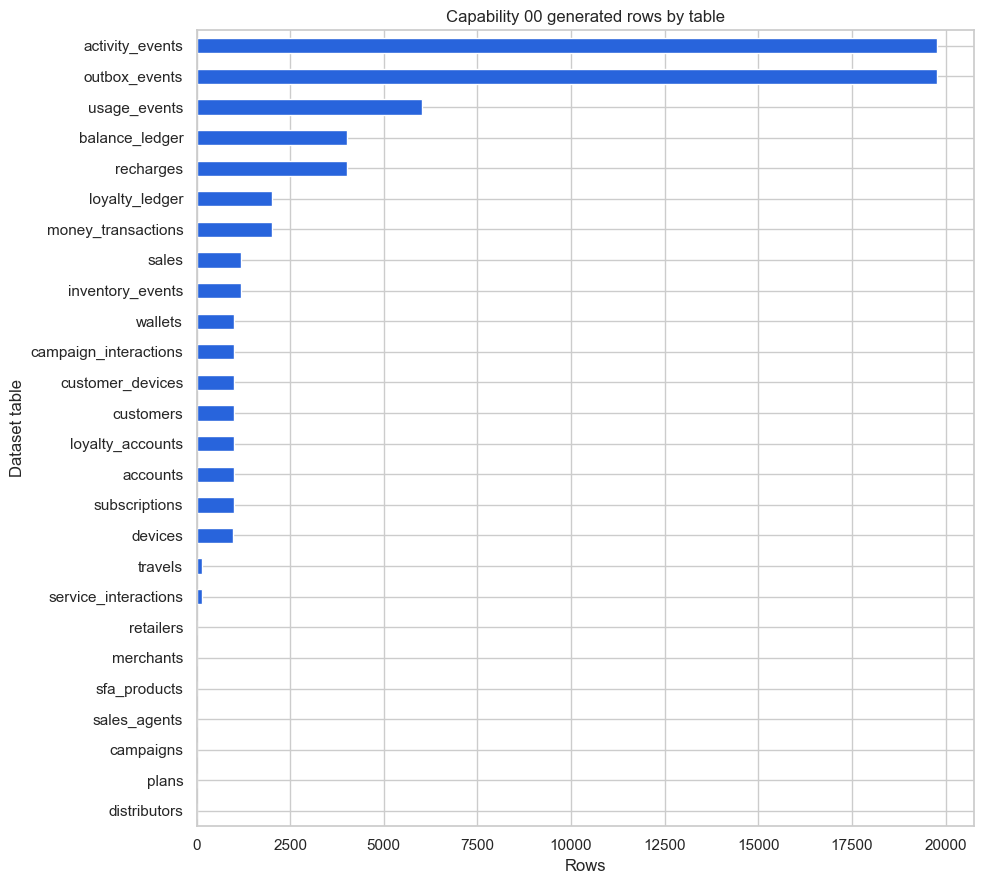

In [2]:
row_counts = pd.Series(metrics['row_counts']).sort_values()
row_counts.rename_axis('table').reset_index(name='rows').to_json(
    tables_dir / 'table_row_counts.json', orient='records', indent=2
)
ax = row_counts.plot.barh(figsize=(10, 9), color='#2864dc')
ax.set(title='Capability 00 generated rows by table', xlabel='Rows', ylabel='Dataset table')
plt.tight_layout()
plt.savefig(plots_dir / 'table_row_counts.png', dpi=160)
plt.show()

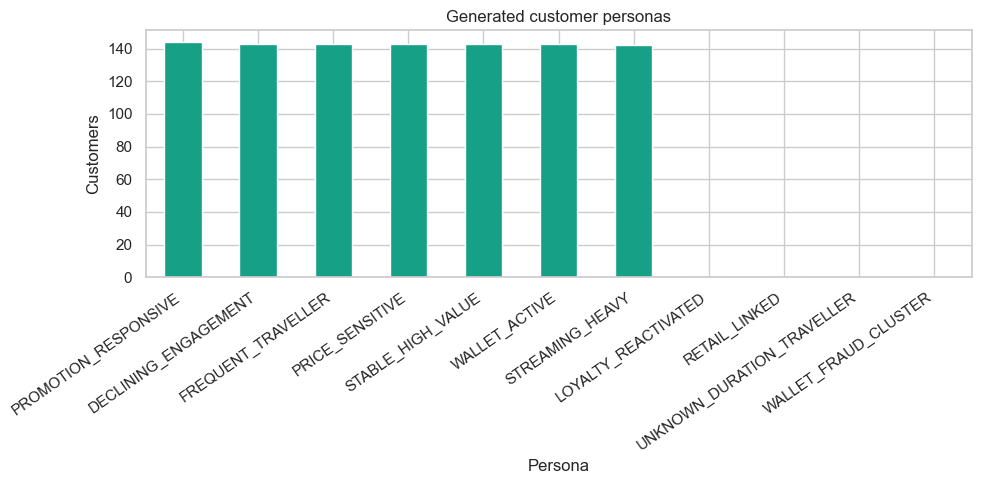

In [3]:
personas = pd.Series(metrics['persona_counts']).sort_values(ascending=False)
personas.rename_axis('persona').reset_index(name='customers').to_json(
    tables_dir / 'persona_distribution.json', orient='records', indent=2
)
ax = personas.plot.bar(figsize=(10, 5), color='#16a085')
ax.set(title='Generated customer personas', xlabel='Persona', ylabel='Customers')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(plots_dir / 'persona_distribution.png', dpi=160)
plt.show()

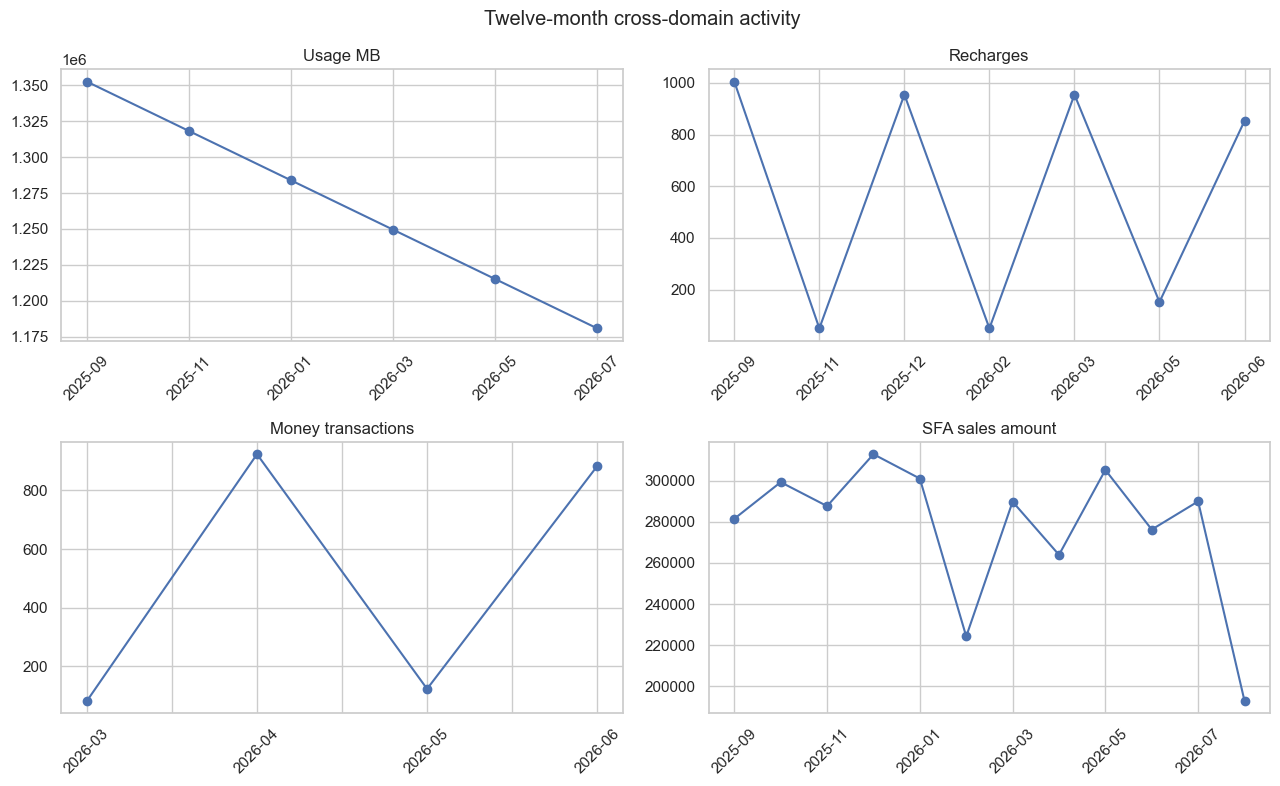

In [4]:
series = {
    'Usage MB': pd.Series(metrics['monthly_usage_mb'], dtype=float),
    'Recharges': pd.Series(metrics['monthly_recharges'], dtype=float),
    'Money transactions': pd.Series(metrics['monthly_transactions'], dtype=float),
    'SFA sales amount': pd.Series(metrics['monthly_sales_amount'], dtype=float),
}
pd.DataFrame(series).rename_axis('month').reset_index().to_json(
    tables_dir / 'monthly_activity_trends.json', orient='records', indent=2
)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, values) in zip(axes.flat, series.items(), strict=True):
    values.plot(ax=ax, marker='o')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Twelve-month cross-domain activity')
fig.tight_layout()
plt.savefig(plots_dir / 'monthly_activity_trends.png', dpi=160)
plt.show()

## Interpretation

The deterministic dataset supplies enough temporal and cross-domain variation for later feature, memory, churn, recommendation, fraud, forecasting, twin, and decisioning POC stages. Synthetic distributions are scenario fixtures, not estimates of real customer behavior.